In [1]:
# =============================================================================
# UNSW-NB15 DATASET: CYBERSECURITY ANALYTICS
# =============================================================================
# Models: K-Nearest Neighbors (KNN) & Support Vector Machine (SVM)
# 1. Dataset Concatenation (Train + Test Files)
# 2. 10 Strategic & Simple EDA Visualizations
# 3. Manual Random Oversampling for Balanced Classes
# 4. Performance Evaluation & Rank Table
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import warnings

# --- Global Style Setup ---
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="bright")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# -----------------------------------------------------------------------------
# STEP 1: LOAD & CONCATENATE DATASETS
# -----------------------------------------------------------------------------
try:
    train_df = pd.read_csv('UNSW_NB15_training-set.csv')
    test_df = pd.read_csv('UNSW_NB15_testing-set.csv')

    # Merge both files
    df = pd.concat([train_df, test_df], ignore_index=True)

    if 'id' in df.columns:
        df.drop('id', axis=1, inplace=True)

    print(f"✓ Dataset Unified. Total Records: {df.shape[0]}")
except Exception as e:
    print(f"Error loading files: {e}")

✓ Dataset Unified. Total Records: 257673


In [3]:
df.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,0.000011,udp,-,INT,2,0,496,0,90909.0902,254,...,1,2,0,0,0,1,2,0,Normal,0
1,0.000008,udp,-,INT,2,0,1762,0,125000.0003,254,...,1,2,0,0,0,1,2,0,Normal,0
2,0.000005,udp,-,INT,2,0,1068,0,200000.0051,254,...,1,3,0,0,0,1,3,0,Normal,0
3,0.000006,udp,-,INT,2,0,900,0,166666.6608,254,...,1,3,0,0,0,2,3,0,Normal,0
4,0.000010,udp,-,INT,2,0,2126,0,100000.0025,254,...,1,3,0,0,0,2,3,0,Normal,0


In [4]:
df.tail()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
257668,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,13,24,0,0,0,24,24,0,Generic,1
257669,0.505762,tcp,-,FIN,10,8,620,354,33.612649,254,...,1,2,0,0,0,1,1,0,Shellcode,1
257670,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,3,13,0,0,0,3,12,0,Generic,1
257671,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,14,30,0,0,0,30,30,0,Generic,1
257672,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,16,30,0,0,0,30,30,0,Generic,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257673 entries, 0 to 257672
Data columns (total 44 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   dur                257673 non-null  float64
 1   proto              257673 non-null  object 
 2   service            257673 non-null  object 
 3   state              257673 non-null  object 
 4   spkts              257673 non-null  int64  
 5   dpkts              257673 non-null  int64  
 6   sbytes             257673 non-null  int64  
 7   dbytes             257673 non-null  int64  
 8   rate               257673 non-null  float64
 9   sttl               257673 non-null  int64  
 10  dttl               257673 non-null  int64  
 11  sload              257673 non-null  float64
 12  dload              257673 non-null  float64
 13  sloss              257673 non-null  int64  
 14  dloss              257673 non-null  int64  
 15  sinpkt             257673 non-null  float64
 16  di

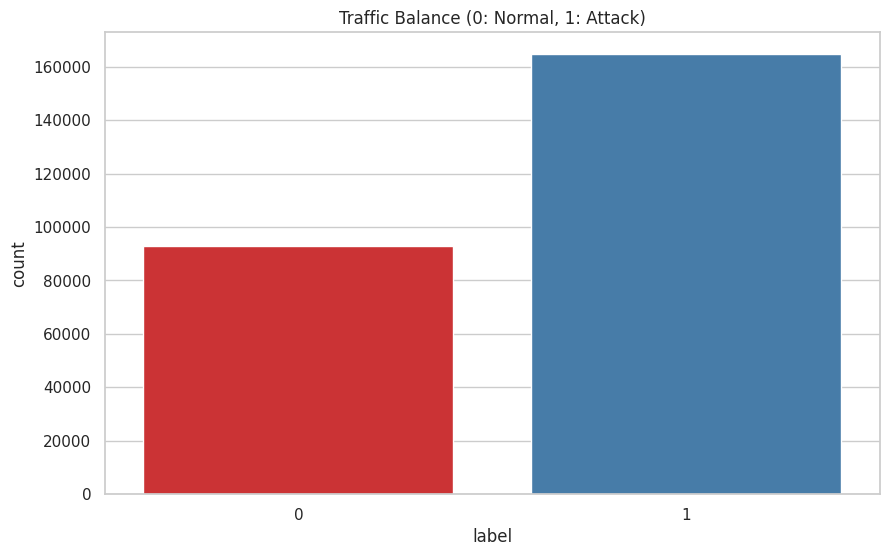

In [6]:
plt.figure()
sns.countplot(x='label', data=df, palette='Set1')
plt.title('Traffic Balance (0: Normal, 1: Attack)')
plt.show()

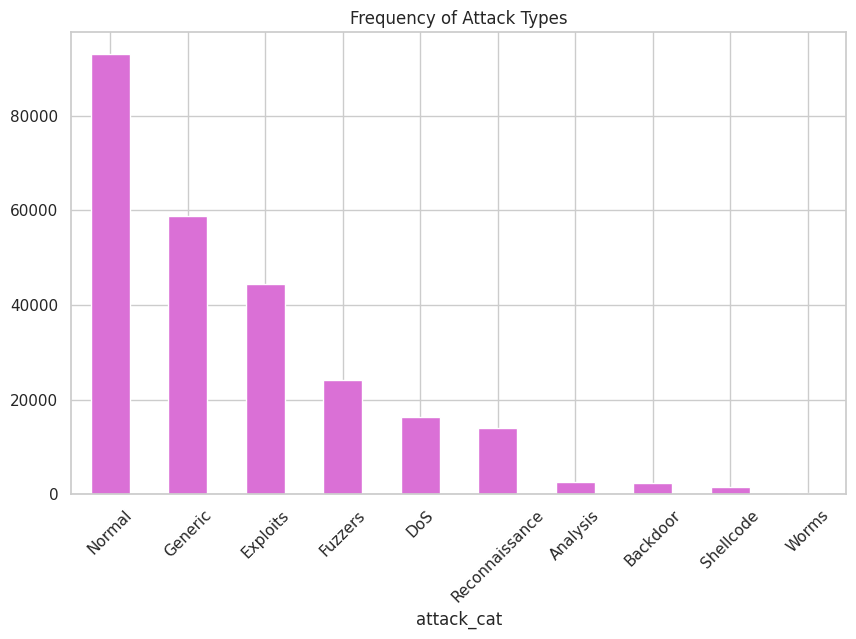

In [7]:
plt.figure()
df['attack_cat'].value_counts().plot(kind='bar', color='orchid')
plt.title('Frequency of Attack Types')
plt.xticks(rotation=45)
plt.show()

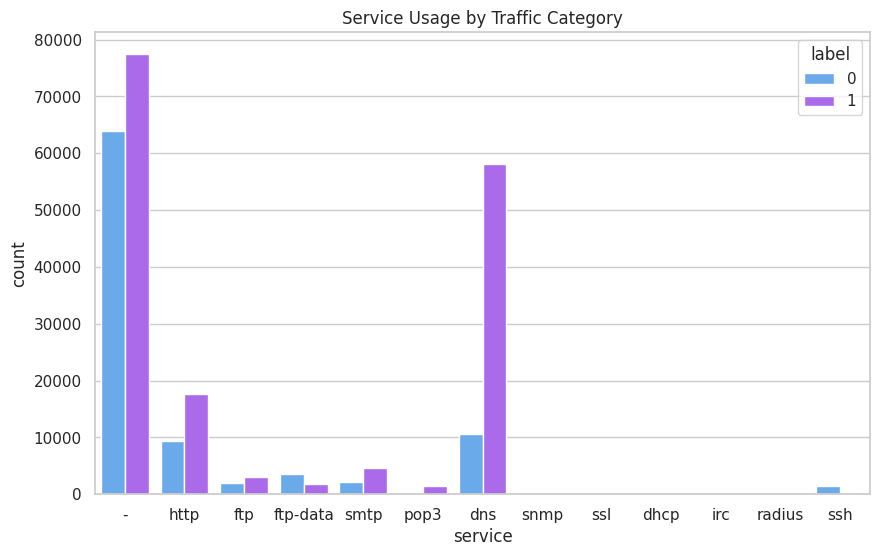

In [9]:
plt.figure()
sns.countplot(x='service', hue='label', data=df, palette='cool')
plt.title('Service Usage by Traffic Category')
plt.show()

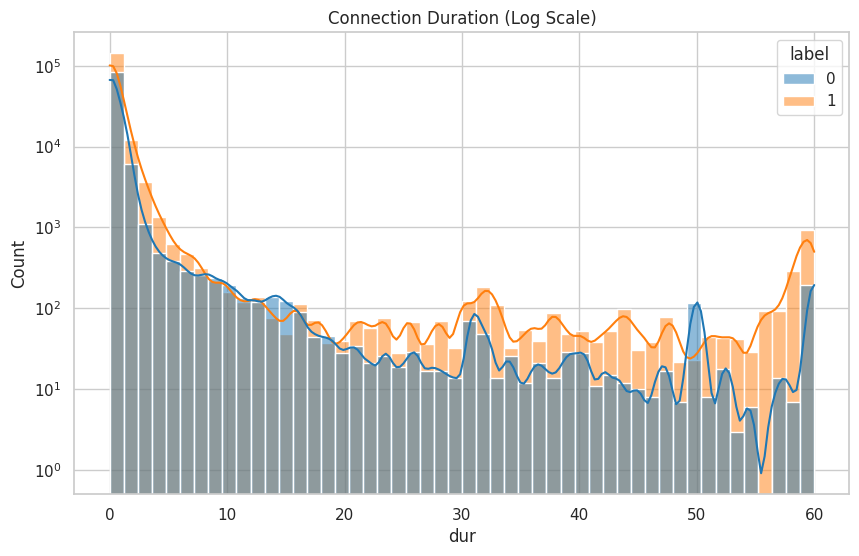

In [11]:
plt.figure()
sns.histplot(df, x='dur', hue='label', bins=50, kde=True, palette='tab10')
plt.yscale('log')
plt.title('Connection Duration (Log Scale)')
plt.show()

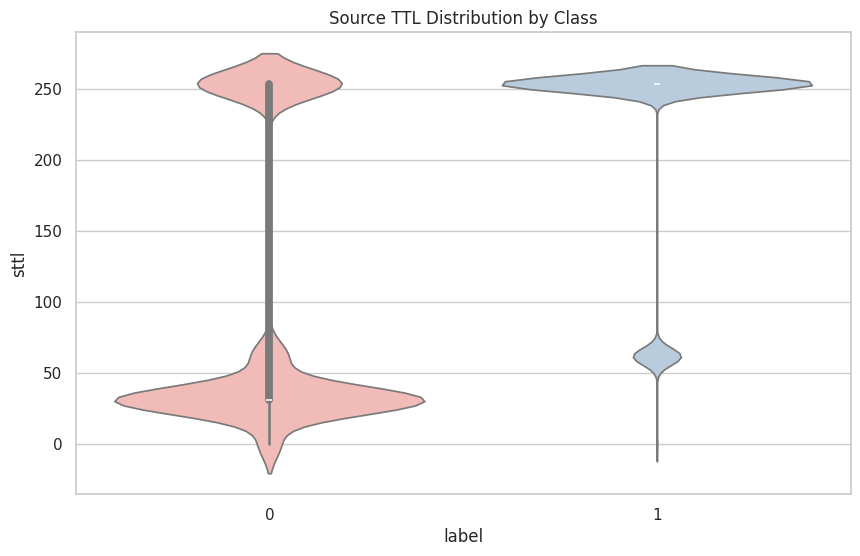

In [14]:
plt.figure()
sns.violinplot(x='label', y='sttl', data=df, palette='Pastel1')
plt.title('Source TTL Distribution by Class')
plt.show()

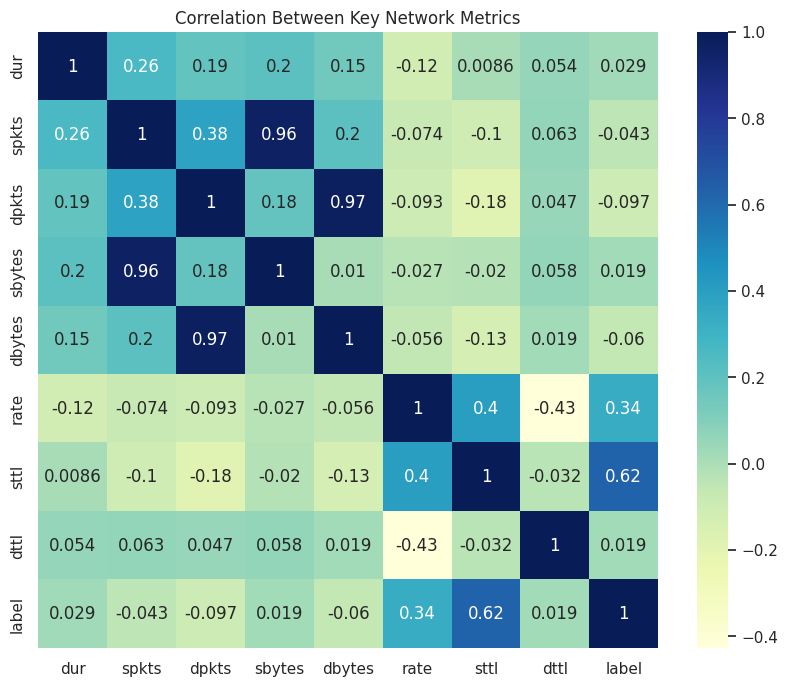

In [15]:
plt.figure(figsize=(10, 8))
cols = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'label']
sns.heatmap(df[cols].corr(), annot=True, cmap='YlGnBu')
plt.title('Correlation Between Key Network Metrics')
plt.show()

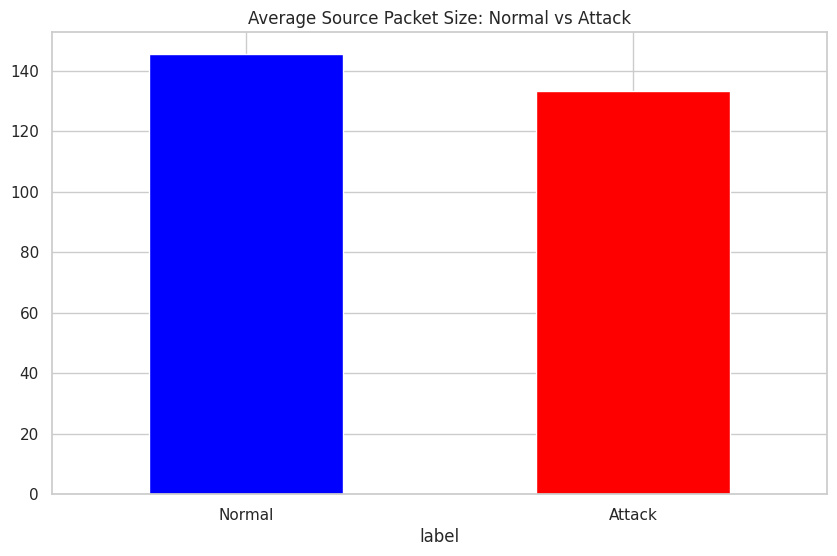

In [16]:
plt.figure()
df.groupby('label')['smean'].mean().plot(kind='bar', color=['blue', 'red'])
plt.title('Average Source Packet Size: Normal vs Attack')
plt.xticks([0, 1], ['Normal', 'Attack'], rotation=0)
plt.show()

In [17]:
# -----------------------------------------------------------------------------
# STEP 3: PRE-PROCESSING & MANUAL OVERSAMPLING
# -----------------------------------------------------------------------------
# Downsample for computational efficiency (especially for SVM)
df_sub = df.sample(n=min(len(df), 20000), random_state=42)

# Encoding
le = LabelEncoder()
for col in ['proto', 'service', 'state']:
    df_sub[col] = le.fit_transform(df_sub[col].astype(str))

# Features and Target
X = df_sub.drop(['label', 'attack_cat'], axis=1)
y = df_sub['label']

X_train_raw, X_test, y_train_raw, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- MANUAL RANDOM OVERSAMPLING ---
train_data = pd.concat([X_train_raw, y_train_raw], axis=1)
df_maj = train_data[train_data.label == 1]
df_min = train_data[train_data.label == 0]

# Sample Normal (minority) to match Attack (majority)
df_min_upsampled = resample(df_min, replace=True, n_samples=len(df_maj), random_state=42)
train_balanced = pd.concat([df_maj, df_min_upsampled])

X_train = train_balanced.drop('label', axis=1)
y_train = train_balanced['label']

# Scaling (Essential for KNN and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
# -----------------------------------------------------------------------------
# STEP 4: MODEL TRAINING (KNN & SVM)
# -----------------------------------------------------------------------------
results = []

# --- Model 1: K-Nearest Neighbors ---
print("\nTraining K-Nearest Neighbors...")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_preds = knn.predict(X_test_scaled)

results.append({
    "Algorithm": "K-Nearest Neighbors",
    "Accuracy": round(accuracy_score(y_test, knn_preds), 4),
    "Precision": round(precision_score(y_test, knn_preds), 4),
    "Recall": round(recall_score(y_test, knn_preds), 4),
    "F1-Score": round(f1_score(y_test, knn_preds), 4)
})

# --- Model 2: Support Vector Machine ---
print("Training Support Vector Machine...")
svm = SVC(kernel='rbf', C=1.0, random_state=42)
svm.fit(X_train_scaled, y_train)
svm_preds = svm.predict(X_test_scaled)

results.append({
    "Algorithm": "Support Vector Machine",
    "Accuracy": round(accuracy_score(y_test, svm_preds), 4),
    "Precision": round(precision_score(y_test, svm_preds), 4),
    "Recall": round(recall_score(y_test, svm_preds), 4),
    "F1-Score": round(f1_score(y_test, svm_preds), 4)
})


Training K-Nearest Neighbors...
Training Support Vector Machine...


In [21]:
# -----------------------------------------------------------------------------
# STEP 5: FINAL PERFORMANCE RANK TABLE
# -----------------------------------------------------------------------------
rank_table = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
rank_table.index += 1
rank_table.index.name = "Rank"

print("\n" + "="*70)
print(" MACHINE LEARNING PERFORMANCE RANK TABLE")
print("="*70)
print(rank_table)


 MACHINE LEARNING PERFORMANCE RANK TABLE
                   Algorithm  Accuracy  Precision  Recall  F1-Score
Rank                                                               
1     Support Vector Machine    0.8995     0.9462  0.8926    0.9186
2        K-Nearest Neighbors    0.8945     0.9366  0.8946    0.9151


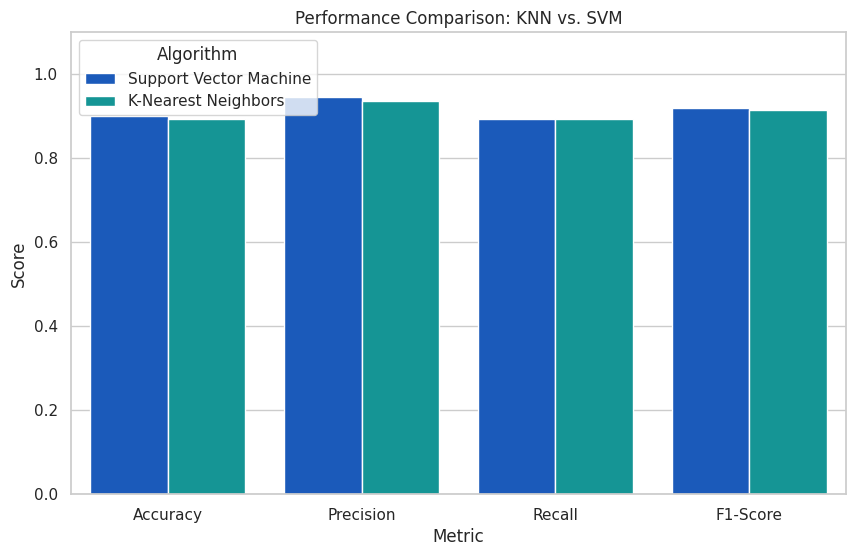

In [22]:
# Comparison Bar Plot
plt.figure()
melted = rank_table.melt(id_vars='Algorithm', var_name='Metric', value_name='Score')
sns.barplot(x='Metric', y='Score', hue='Algorithm', data=melted, palette='winter')
plt.title('Performance Comparison: KNN vs. SVM')
plt.ylim(0, 1.1)
plt.show()